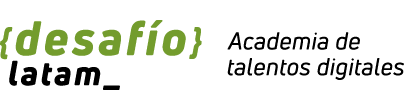

# <font color = 'green'> Procesamiento de texto y críticas de películas </font>

Usaremos una base de datos de críticas de películas con clasificación positiva o negativa. Son 25.000 críticas para entrenamiento y 25.000 para test, que por motivos de simplificación ya separamos en diferentes dataframes y limpiamos el texto correspondiente. Los datos han sido extraídos de

https://ai.stanford.edu/~amaas/data/sentiment/

@InProceedings{maas-EtAl:2011:ACL-HLT2011,
  author    = {Maas, Andrew L.  and  Daly, Raymond E.  and  Pham, Peter T.  and  Huang, Dan  and  Ng, Andrew Y.  and  Potts, Christopher},
  title     = {Learning Word Vectors for Sentiment Analysis},
  booktitle = {Proceedings of the 49th Annual Meeting of the Association for Computational Linguistics: Human Language Technologies},
  month     = {June},
  year      = {2011},
  address   = {Portland, Oregon, USA},
  publisher = {Association for Computational Linguistics},
  pages     = {142--150},
  url       = {http://www.aclweb.org/anthology/P11-1015}
}

Al descomprimir la base de datos en un directorio se obtiene la carpeta 'aclImbd', en la cual se aplicó el siguiente código para separar los datos, limpiarlos y guardarlos

In [ ]:

'''
fld = 'aclImdb/train/'
get_list_files = lambda fld: [join(fld, ff) for ff in listdir(fld) if (isfile(join(fld, ff)) and (ff.endswith('.txt')))]

df_train = pd.DataFrame({'doc':pd.Series(dtype='object'), 'lbl':pd.Series(dtype='int')})
df_test = pd.DataFrame({'doc':pd.Series(dtype='object'), 'lbl':pd.Series(dtype='int')})

categories = {'neg': 0, 'pos': 1}
segments = {'train': df_train, 'test': df_test}

for seg, df in segments.items():
    path = 'aclImdb/' + seg + '/'
    for lbl, value in categories.items():
        list_file_train = get_list_files(path + lbl)
        for ff in list_file_train:
            with open(ff, 'r') as f:
                text = f.read()
                df = pd.concat([df, pd.DataFrame({'doc':[text], 'lbl':[value]})], ignore_index=True, axis=0)
    if seg == 'train':
        df_train = df
    else:
        df_test = df


# Limpieza

df_train['doc'] = df_train['doc'].apply(lambda txt: re.sub(re.compile('<.*?>'), '', txt))
df_test['doc'] = df_test['doc'].apply(lambda txt: re.sub(re.compile('<.*?>'), '', txt))

df_train.to_csv('train.csv', index=False)
df_test.to_csv('test.csv', index=False)
'''

#### Carga de datos

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from wordcloud import WordCloud

import re
from os import system, listdir
from os.path import isfile, join
from gensim.models import Word2Vec
from keras.preprocessing.text import Tokenizer
from keras.utils import pad_sequences
import multiprocessing
from keras.layers import Embedding
from keras.models import Sequential
from keras.layers import LSTM, Dense
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import classification_report, roc_curve, roc_auc_score

In [ ]:
df_train=pd.read_csv('train.csv')
df_test=pd.read_csv('test.csv')

In [ ]:
df_total = pd.concat([df_train, df_test], axis=0, ignore_index=True)
df_total['doc'] = df_total['doc'].apply(lambda txt: re.sub(re.compile('<.*?>'), '', txt))

In [ ]:
df_train.head(5)

,doc,lbl
0,"Now look, I won't lie to you, but I only got t...",0
1,Interesting story about a soldier in a war who...,0
2,Awful movie. It's a shame that a few of Flande...,0
3,My girlfriend and I were stunned by how bad th...,0
4,First let me be honest. I did not watch all th...,0


In [ ]:
df_test.head()

,doc,lbl
0,What a waste of energy and money. What a waste...,0
1,(Spoilers)Oh sure it's based on Moby Dick. Tot...,0
2,I must have been in a good mood to give this s...,0
3,"I love the first and third Beastmasters, but t...",0
4,Last week I watched a Royal Shakespeare Compan...,0


#### Explorar palabras más frecuentes

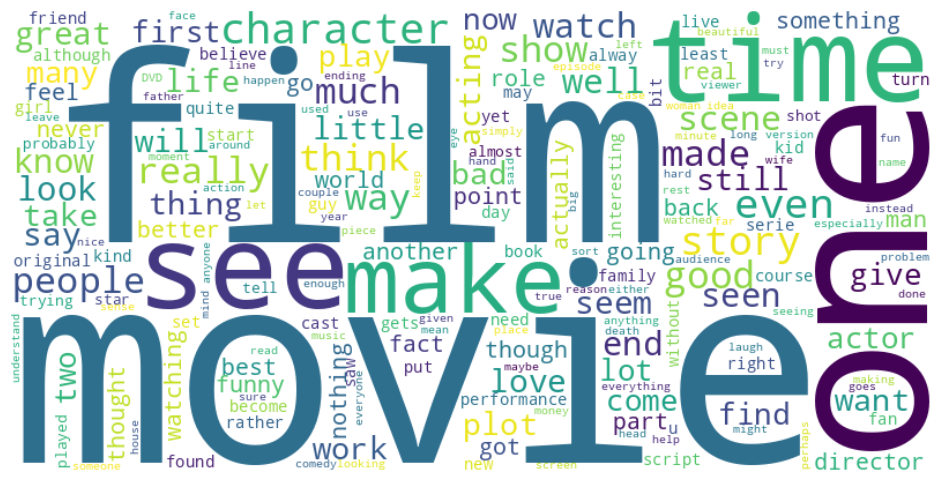

In [ ]:
# Join all reviews into a single string
opiniones = ' '.join(df_train['doc'])

# Generate a word cloud image
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(opiniones)

# Display the generated image:
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

#### Se separa los datos en X and y

In [ ]:
X_data = df_total['doc'].to_numpy()
y_data = df_total['lbl'].to_numpy()

X_train = df_train['doc'].to_numpy()
y_train = df_train['lbl'].to_numpy()

X_test = df_test['doc'].to_numpy()
y_test = df_test['lbl'].to_numpy()

#### Crear y entrenar un Word Embedding

In [ ]:
# Cantidad de caracteristicas que se entrenarán para representar cada palabra
embedding_dim = 100

# creamos una lista de documentos en que cada documento será una lista de palabras
w2vec_train_data = list(map(lambda x: x.split(), X_data))

#########################################
### creamos y entrenamos los embedding
#########################################

# Detectar cantidad de core disponibles
cores = multiprocessing.cpu_count()

# Defining the model and training it.
word2vec_model = Word2Vec(
    w2vec_train_data,
    vector_size=embedding_dim,
    workers=cores-1,
    min_count=5 # ignorar aquellas palabras que aparecen min_count o menos veces en el corpus
)

#### Tokenizar documentos y aplicar padding

In [ ]:
# tamaño fijo para cada secuencia
n_secuencia = 80

# cantidad máxima de palabras a usar en
# el vocabulario
num_words = 80000

tokenizer = Tokenizer(num_words=num_words,lower=False, oov_token="<oov>")
tokenizer.fit_on_texts(X_data)

# este límite de palabras se aplica cuando se pasan los tokens a sequences.

In [ ]:
# cada doc tokenizado es representado númericamente y luego se aplica el padding
X_train = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=n_secuencia)
X_test  = pad_sequences(tokenizer.texts_to_sequences(X_test) , maxlen=n_secuencia)

print("X_train.shape:", X_train.shape)
print("X_test.shape :", X_test.shape)

X_train.shape: (25000, 80)
X_test.shape : (25000, 80)


#### Creamos la matriz con los embedding
Filas cada palabra del vocabulario y columnas la codificación númerica de cada una

In [ ]:
def get_embedding_matrix(word2vec_model, tokenizer, num_words, embedding_dim):

    num_words_ = min(num_words, len(tokenizer.word_index)) + 1
    embedding_matrix = np.zeros((num_words_, embedding_dim))
    print(num_words_)

    if isinstance(word2vec_model, Word2Vec):
        word2vec_model = word2vec_model.wv

    for word, i in tokenizer.word_index.items():
        if i >= num_words_:
            continue

        if word in word2vec_model:
            embedding_matrix[i] = word2vec_model[word]
        else:
            embedding_matrix[i] = np.zeros(embedding_dim)

    return num_words_, embedding_matrix

In [ ]:
embedding_dim = 100
num_words, embedding_matrix = get_embedding_matrix(word2vec_model, tokenizer, num_words, embedding_dim)

80001


#### Creamos nuestro modelo de red neuronal LSTM considerando nuestros embedding

In [ ]:
def get_model_lstm():

    capa_embedding = Embedding(input_dim=num_words,
                                output_dim=embedding_dim,
                                weights=[embedding_matrix],
                                input_length=n_secuencia,
                                trainable=False)

    model = Sequential()
    model.add(capa_embedding)
    model.add(LSTM(100, dropout=0.3, return_sequences=True))
    model.add(LSTM(100, dropout=0.3, return_sequences=True))
    model.add(LSTM(100, dropout=0.3, return_sequences=False))
    model.add(Dense(16, activation='relu'))
    model.add(Dense(2, activation='softmax'))

    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

    return model


training_model = get_model_lstm()
training_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 80, 100)           8000100   
                                                                 
 lstm (LSTM)                 (None, 80, 100)           80400     
                                                                 
 lstm_1 (LSTM)               (None, 80, 100)           80400     
                                                                 
 lstm_2 (LSTM)               (None, 100)               80400     
                                                                 
 dense (Dense)               (None, 16)                1616      
                                                                 
 dense_1 (Dense)             (None, 2)                 34        
                                                                 
Total params: 8242950 (31.44 MB)
Trainable params: 24285

In [ ]:
# Se expresa el vector de de etiquetas en las dimensiones correctas
# para el entrenamiento
ohe = OneHotEncoder()
y_train_ = ohe.fit_transform(y_train.reshape(-1, 1)).toarray()
y_test_ = ohe.fit_transform(y_test.reshape(-1, 1)).toarray()

In [ ]:
epochs = 12
history = training_model.fit(
    X_train, y_train_,
    batch_size=64,
    epochs=epochs,
    validation_data=[X_test, y_test_],
    #validation_split=0.1,
    #callbacks=callbacks,
    verbose=1,
)

Epoch 1/12
391/391 [==============================] - 199s 491ms/step - loss: 0.5636 - accuracy: 0.7144 - val_loss: 0.4977 - val_accuracy: 0.7671
Epoch 2/12
391/391 [==============================] - 221s 565ms/step - loss: 0.4724 - accuracy: 0.7738 - val_loss: 0.3978 - val_accuracy: 0.8166
Epoch 3/12
391/391 [==============================] - 222s 569ms/step - loss: 0.4271 - accuracy: 0.8013 - val_loss: 0.3822 - val_accuracy: 0.8270
Epoch 4/12
391/391 [==============================] - 222s 569ms/step - loss: 0.4004 - accuracy: 0.8178 - val_loss: 0.3451 - val_accuracy: 0.8464
Epoch 5/12
391/391 [==============================] - 223s 570ms/step - loss: 0.3786 - accuracy: 0.8247 - val_loss: 0.3407 - val_accuracy: 0.8477
Epoch 6/12
391/391 [==============================] - 234s 600ms/step - loss: 0.3591 - accuracy: 0.8384 - val_loss: 0.3258 - val_accuracy: 0.8577
Epoch 7/12
391/391 [==============================] - 226s 577ms/step - loss: 0.3429 - accuracy: 0.8464 - val_loss: 0.3478 -

### Predicciones

In [ ]:
# Probabilidad de sentimiento positivo
yhat = training_model.predict(X_test)
yhat_class = np.where(yhat[:, 1] > 0.5, 1, 0)

print(classification_report(y_test, yhat_class))

782/782 [==============================] - 46s 57ms/step
              precision    recall  f1-score   support

           0       0.86      0.88      0.87     12500
           1       0.88      0.86      0.87     12500

    accuracy                           0.87     25000
   macro avg       0.87      0.87      0.87     25000
weighted avg       0.87      0.87      0.87     25000



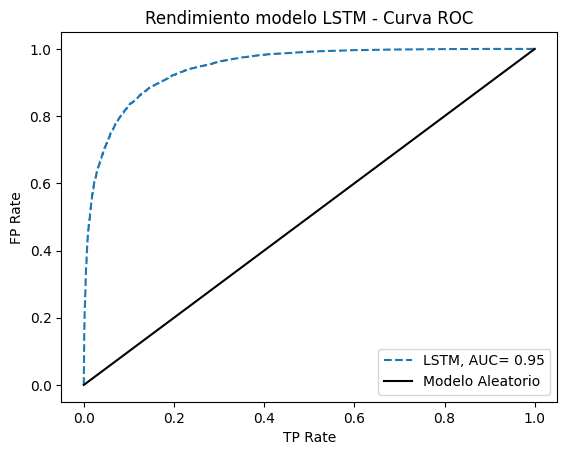

In [ ]:
# Curva ROC

fpr, tpr, _ = roc_curve(y_test, yhat[:, 1])
auc = roc_auc_score(y_test, yhat[:, 1])
plt.plot(fpr, tpr, '--', label=f'LSTM, AUC= {np.round(auc, 2)}')
plt.plot([0.0, 1.0], [0.0, 1.0], '-', color='black', label='Modelo Aleatorio')
plt.legend()
plt.title('Rendimiento modelo LSTM - Curva ROC')
plt.xlabel('TP Rate')
plt.ylabel('FP Rate')
plt.show();

### Predicciones puntuales

In [ ]:
# Muestra de aleatoria de observaciones del conjunto de test

df_test_sample = df_test.sample(7, random_state=1146)
df_test_sample

,doc,lbl
13967,Malcolm McDowell diagnoses Megan Gallagher's d...,1
17477,"The Squire of Gothos is one of the ""sillier"" e...",1
10803,"""Get Shorty"", ""Out of Sight"", ""Jackie Brown"" (...",0
13090,"This little film is hysterical, full of stereo...",1
18470,This movie is the best movie I have seen in a ...,1
21937,"This film is pretty good, it actually is like ...",1
13784,I was at a friends house for Thanksgiving and ...,1


In [ ]:
# Predicciones

idx_test_sample = np.array(df_test_sample.index)
yhat = training_model.predict(X_test[idx_test_sample])
yhat_class = np.where(yhat[:, 1] > 0.5, 1, 0)

df_test_sample['lbl_predict'] = yhat_class
df_test_sample

1/1 [==============================] - 0s 40ms/step


,doc,lbl,lbl_predict
13967,Malcolm McDowell diagnoses Megan Gallagher's d...,1,1
17477,"The Squire of Gothos is one of the ""sillier"" e...",1,0
10803,"""Get Shorty"", ""Out of Sight"", ""Jackie Brown"" (...",0,0
13090,"This little film is hysterical, full of stereo...",1,1
18470,This movie is the best movie I have seen in a ...,1,1
21937,"This film is pretty good, it actually is like ...",1,1
13784,I was at a friends house for Thanksgiving and ...,1,1


In [ ]:
text_new_true = 1 # positive
text_new = "I saw this film some years ago and promptly bought the soundtrack because it was simply excellent. Bacharach's music is endearing and should be given the recognition it richly deserves. The cinematography is awesome. Critics hated it, but they hated HOME ALONE too. I haven't found it on video but welcome anyone who can find a copy."
text_new_seq = pad_sequences(tokenizer.texts_to_sequences([text_new]), maxlen=n_secuencia)


yhat2 = training_model.predict(text_new_seq)
yhat2_class = np.where(yhat2[:, 1] > 0.5, 1, 0)
print(f'Prediction: {yhat2_class}')


1/1 [==============================] - 0s 52ms/step
Prediction: [1]


In [ ]:
text_new_true = 0 # negative
text_new = "the movie is horrible, boring, slow and I don't like it at all."

text_new_seq = pad_sequences(tokenizer.texts_to_sequences([text_new]), maxlen=n_secuencia)

yhat2 = training_model.predict(text_new_seq)
yhat2_class = np.where(yhat2[:, 1] > 0.5, 1, 0)
print(f'Prediction: {yhat2_class}')

1/1 [==============================] - 0s 49ms/step
Prediction: [0]
